In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,roc_curve,auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
from sklearn.preprocessing import label_binarize

In [21]:
iris_data=load_iris()
feature=iris_data.data
target=iris_data.target
target=label_binarize(target,classes=[0,1,2])

In [22]:
x_train,x_test,y_train,y_test=train_test_split(feature,target,test_size=0.2,random_state=42)

In [23]:
model1=LogisticRegression().fit(x_train,y_train[:,0])
model2=LogisticRegression().fit(x_train,y_train[:,1])
model3=LogisticRegression().fit(x_train,y_train[:,2])

In [24]:
print("model accuracy")
print(f"model1.{model1.score(x_test,y_test[:,0])}")
print(f"model2.{model2.score(x_test,y_test[:,1])}")
print(f"model3.{model3.score(x_test,y_test[:,2])}")

model accuracy
model1.1.0
model2.0.8
model3.1.0


In [25]:
model=OneVsRestClassifier(LogisticRegression()).fit(x_train,y_train)

In [26]:
prob_test=model.predict_proba(x_test)

In [28]:
n_classes=3
fpr=[0]*3
tpr=[0]*3
threshold=[0]*3
auc_score=[0]*3
for i in range(n_classes):
    fpr[i],tpr[i],threshold[i]=roc_curve(y_test[:,i],prob_test[:,i])
    auc_score[i]=auc(fpr[i],tpr[i])
    
auc_score

[1.0, 0.8253968253968254, 1.0]

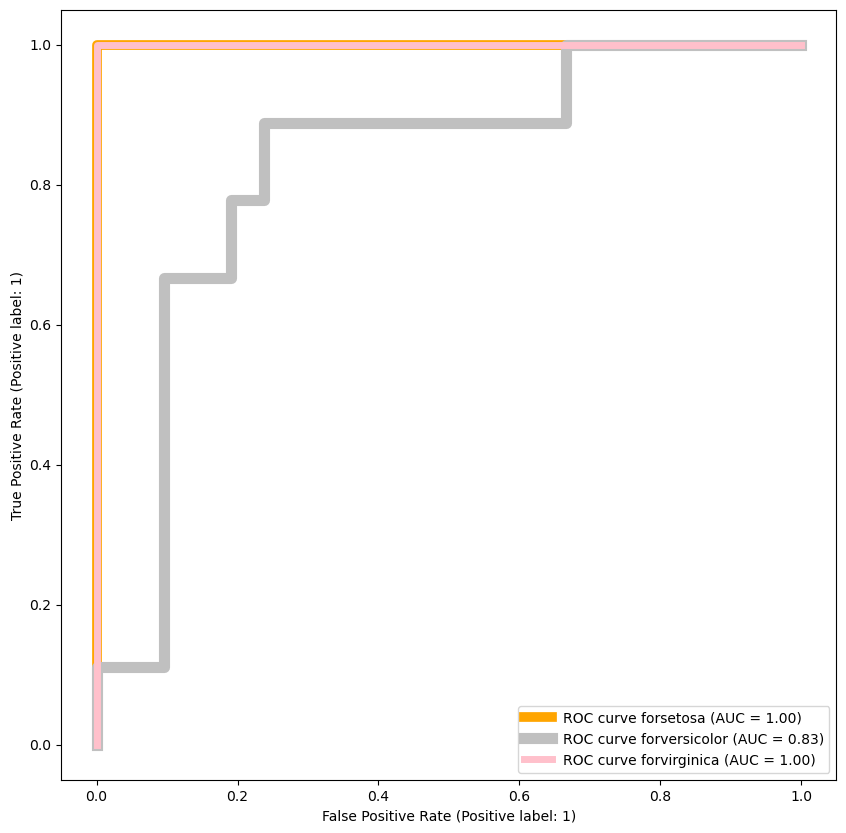

In [35]:
import random
fig,ax=plt.subplots(figsize=(10,10))
target_names=iris_data.target_names
colors=cycle(["orange","silver","pink"])
for class_id,color in zip(range(n_classes),colors):
    RocCurveDisplay.from_predictions(y_test[:,class_id],prob_test[:,class_id],
                                    name=f"ROC curve for{target_names[class_id]}",color=color,ax=ax,
                                    linewidth=random.randint(2,10))